In [65]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "figures" else CWD
FIGDATA = ROOT / "figures" / "figdata" / "long_followup_recovery"
OUTPUT_DIR = ROOT / "figures" / "outputs" / "long_followup_recovery"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

YEARLY_METRICS = FIGDATA / "yearly_metrics.csv"
SOURCE_MANIFEST = FIGDATA / "source_manifest.json"
BEST_CHECKPOINT = ROOT / "best_ckpt.pt"
DELPHI_CHECKPOINT = FIGDATA / "delphi_ckpt.pt"
HELVETICA = ROOT / "figures" / "figutil" / "Helvetica.ttf"

assert HELVETICA.exists(), f"Missing Helvetica font: {HELVETICA}"
font_manager.fontManager.addfont(HELVETICA)

plt.rcParams.update({
    "font.family": "Helvetica",
    "pdf.fonttype": 3,
    "ps.fonttype": 3,
    "axes.linewidth": 1.2,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

### Data

In [67]:
def sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


manifest = json.loads(SOURCE_MANIFEST.read_text())
yearly = pd.read_csv(YEARLY_METRICS)

assert sha256(YEARLY_METRICS) == manifest["chart_data"]["sha256"]
assert sha256(BEST_CHECKPOINT) == manifest["best_checkpoint"]["sha256"]
assert sha256(DELPHI_CHECKPOINT) == manifest["delphi_checkpoint"]["sha256"]

expected_models = {"Best checkpoint (0909)", "Original Delphi"}
assert set(yearly["model"]) == expected_models
for model in expected_models:
    model_years = yearly.loc[yearly.model == model, "followup_year_bin"].tolist()
    assert model_years == list(range(1, 20))

n_pivot = yearly.pivot(
    index="followup_year_bin",
    columns="model",
    values="people_with_observed_token_denominator",
).sort_index()
assert (n_pivot["Best checkpoint (0909)"] == n_pivot["Original Delphi"]).all()
expected_tail = {14: 283, 15: 165, 16: 115, 17: 48, 18: 13, 19: 2}
assert n_pivot.loc[14:19, "Best checkpoint (0909)"].astype(int).to_dict() == expected_tail

# print("Input validation: PASS")
# display(yearly.loc[yearly.followup_year_bin >= 14, [
#     "model", "followup_year_bin", "people_with_observed_token_denominator",
#     "recovery_weighted", "precision_weighted"
# ]].reset_index(drop=True))

### Results

In [3]:
MODEL_ORDER = ["Best checkpoint (0909)", "Original Delphi"]
MODEL_LABELS = {
    "Best checkpoint (0909)": "DM-CDHNet",
    "Original Delphi": "Delphi-2M",
}
MODEL_COLORS = {
    "Best checkpoint (0909)": "#b2182b",
    "Original Delphi": "#2166ac",
}

def model_values(model: str, first_year: int, last_year: int) -> np.ndarray:
    frame = yearly[
        (yearly.model == model)
        & yearly.followup_year_bin.between(first_year, last_year)
    ].sort_values("followup_year_bin")
    expected = list(range(first_year, last_year + 1))
    assert frame.followup_year_bin.tolist() == expected
    return frame.recovery_weighted.to_numpy(float)


def draw_recovery_figure(max_year: int, dashed_tail: bool):
    years = np.arange(1, max_year + 1)
    n_by_year = n_pivot.loc[years, "Best checkpoint (0909)"].to_numpy(int)
    y_max = 0.40

    fig, (ax, ax_n) = plt.subplots(
        2, 1,
        figsize=(7, 6),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": [4, 1]},
    )

    for model in MODEL_ORDER:
        values = model_values(model, 1, max_year)
        color = MODEL_COLORS[model]
        if dashed_tail:
            # Years 1–14 are the stable solid segment; sparse years 15–19 are dashed.
            solid_last = min(14, max_year)
            ax.stairs(
                values[:solid_last],
                edges=np.arange(0.5, solid_last + 1.5),
                linewidth=2.8,
                color=color,
                label=MODEL_LABELS[model],
                baseline=None,
            )
            if max_year >= 15:
                ax.stairs(
                    values[14:],
                    edges=np.arange(14.5, max_year + 1.5),
                    linewidth=2.4,
                    linestyle="--",
                    alpha=0.60,
                    color=color,
                    baseline=None,
                )
        else:
            # Main-text curve is solid through the final displayed year (17).
            ax.stairs(
                values,
                edges=np.arange(0.5, max_year + 1.5),
                linewidth=2.8,
                color=color,
                label=MODEL_LABELS[model],
                baseline=None,
            )

    ax.set_ylabel("Fraction of observed\ndiagnosis tokens recovered", fontsize=15)
    ax.set_ylim(0, y_max)
    ax.set_yticks(np.arange(0.0, y_max + 0.001, 0.05))
    ax.tick_params(axis="y", length=0, labelsize=12)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.3f"))
    ax.legend(frameon=True, loc="lower left", fontsize=13, handlelength=1.5)
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)

    ax_n.bar(
        years, n_by_year, width=0.82,
        color="#bdbdbd", edgecolor="#636363", linewidth=0.75,
    )
    ax_n.set_yscale("log")
    ax_n.set_ylim(1, 10_000)
    ax_n.set_ylabel("Analysis N\n(log scale)", fontsize=14, labelpad=5)
    ax_n.set_xlabel(
        "Follow-up bin after age 55 (years)",
        fontsize=15,
    )
    ax_n.set_xlim(0.5, max_year + 0.5)
    ax_n.set_xticks(np.arange(1, max_year + 1, 2))
    ax_n.tick_params(axis="both", length=0, labelsize=12)
    ax_n.grid(False, which="both")
    ax_n.spines[["top", "right"]].set_visible(False)
    for year, n_people in zip(years, n_by_year):
        if year >= 14:
            ax_n.text(
                year, n_people * 1.20, f"{int(n_people):,}",
                ha="center", va="bottom", fontsize=10, color="#444444",
            )
    for axis in (ax, ax_n):
        axis.tick_params(axis="both", labelsize=13, width=1.2, length=6)
        axis.spines["left"].set_linewidth(1.2)
        axis.spines["bottom"].set_linewidth(1.2)
    return fig

def save_figure(fig, stem: str):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=900, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return png, pdf

### Main figure — years 1–17

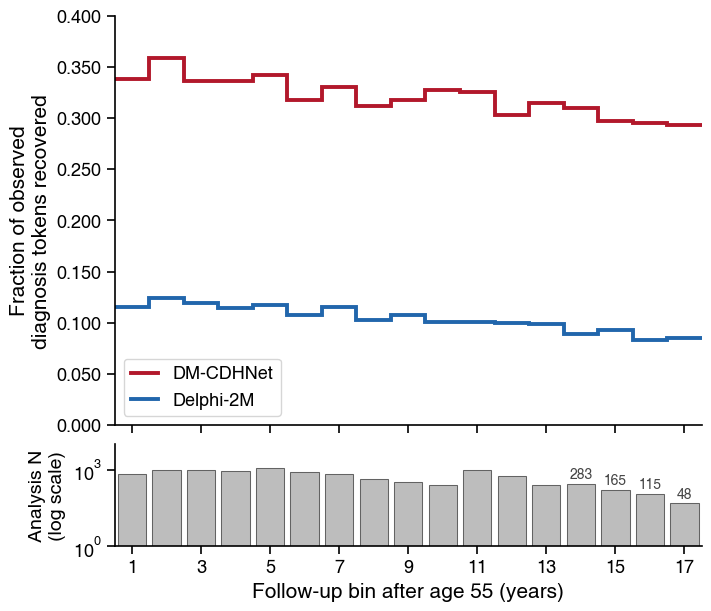

In [4]:
main_figure = draw_recovery_figure(max_year=17, dashed_tail=False)
main_png, main_pdf = save_figure(
    main_figure, "17y_followup"
)
display(main_figure)
plt.close(main_figure)

### Supplementary figure — years 1–19

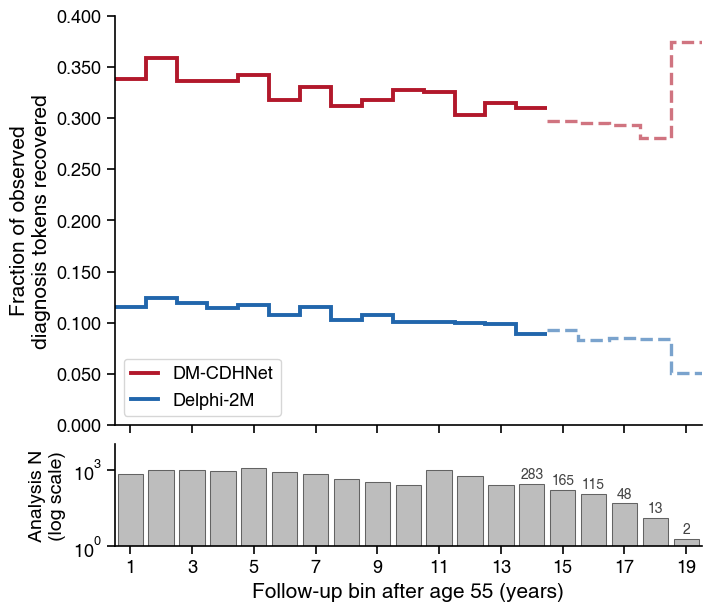

In [5]:
supplementary_figure = draw_recovery_figure(max_year=19, dashed_tail=True)
supplementary_png, supplementary_pdf = save_figure(
    supplementary_figure, "19y_followup"
)
display(supplementary_figure)
plt.close(supplementary_figure)

### Combined overlay — JMDC and UK Biobank

In [62]:
from matplotlib.lines import Line2D

UKB_FIGDATA = ROOT / 'figures' / 'figdata' / 'ukb_long_followup_recovery'
UKB_YEARLY_METRICS = UKB_FIGDATA / 'yearly_metrics.csv'
ukb_manifest = json.loads((UKB_FIGDATA / 'source_manifest.json').read_text())
assert sha256(UKB_YEARLY_METRICS) == ukb_manifest['files']['yearly_metrics.csv']
assert sha256(BEST_CHECKPOINT) == ukb_manifest['sources']['best_ckpt.pt']
assert sha256(DELPHI_CHECKPOINT) == ukb_manifest['sources']['delphi_ckpt.pt']
ukb_yearly = pd.read_csv(UKB_YEARLY_METRICS)
assert set(ukb_yearly.model) == {'DM-CDHNet', 'Delphi-2M'}
assert ukb_yearly.groupby('model').followup_year_bin.apply(list).map(lambda x: x == list(range(1, 21))).all()
assert (ukb_yearly.people_with_observed_token_denominator == 500).all()

COHORT_MARKERS = {'JMDC': 'o', 'UK Biobank': 's'}
SERIES_COLORS = {
    ('DM-CDHNet', 'JMDC'): '#b2182b',
    ('DM-CDHNet', 'UK Biobank'): '#e06b75',
    ('Delphi-2M', 'JMDC'): '#2166ac',
    ('Delphi-2M', 'UK Biobank'): '#74a9cf',
}

def overlay_series_frame(data, source_model, metric, max_year):
    frame = data[(data.model == source_model) & data.followup_year_bin.between(1, max_year)].sort_values('followup_year_bin')
    assert frame.followup_year_bin.tolist() == list(range(1, max_year + 1))
    return frame[['followup_year_bin', metric, 'people_with_observed_token_denominator']].copy()

def draw_jmdc_ukb_overlay():
    fig, (ax, ax_n) = plt.subplots(
        2, 1, figsize=(7.0, 6.0), sharex=True, constrained_layout=True,
        gridspec_kw={'height_ratios': [4, 1]},
    )
    fig.set_constrained_layout_pads(h_pad=0.06, hspace=0.04)

    specs = [
        ('DM-CDHNet', 'JMDC', yearly, 'Best checkpoint (0909)', 'recovery_weighted', 17),
        ('DM-CDHNet', 'UK Biobank', ukb_yearly, 'DM-CDHNet', 'recovery', 20),
        ('Delphi-2M', 'JMDC', yearly, 'Original Delphi', 'recovery_weighted', 17),
        ('Delphi-2M', 'UK Biobank', ukb_yearly, 'Delphi-2M', 'recovery', 20),
    ]
    handles = []
    for model, cohort, data, source_model, metric, max_year in specs:
        frame = overlay_series_frame(data, source_model, metric, max_year)
        years = frame.followup_year_bin.to_numpy(int)
        values = frame[metric].to_numpy(float)
        color = SERIES_COLORS[(model, cohort)]
        marker = COHORT_MARKERS[cohort]
        zorder = 4 if cohort == 'JMDC' else 2
        ax.stairs(values, edges=np.arange(0.5, max_year + 1.5), baseline=None, linewidth=2.5, color=color, zorder=zorder)
        ax.plot(years, values, linestyle='None', marker=marker, markersize=4.8, markerfacecolor='white', markeredgecolor=color, markeredgewidth=1.3, zorder=zorder + 1)
        handles.append(Line2D([0], [0], color=color, linewidth=2.5, marker=marker, markersize=5.5, markerfacecolor='white', markeredgewidth=1.3, label=f'{model} ({cohort})'))

    jmdc_n = overlay_series_frame(yearly, 'Best checkpoint (0909)', 'recovery_weighted', 17)
    ukb_n = overlay_series_frame(ukb_yearly, 'DM-CDHNet', 'recovery', 20)
    bar_width = 0.38
    jmdc_x = jmdc_n.followup_year_bin.to_numpy(float) - bar_width / 2
    ukb_x = ukb_n.followup_year_bin.to_numpy(float) + bar_width / 2
    ax_n.bar(jmdc_x, jmdc_n.people_with_observed_token_denominator, width=bar_width, color='#4d4d4d', edgecolor='black', linewidth=0.8, label='JMDC')
    ax_n.bar(ukb_x, ukb_n.people_with_observed_token_denominator, width=bar_width, color='#969696', edgecolor='black', linewidth=0.8, label='UK Biobank')
    # for year, n_people in zip(jmdc_n.followup_year_bin, jmdc_n.people_with_observed_token_denominator):
    #     if year >= 14:
    #         ax_n.text(year - bar_width / 2, n_people * 1.25, f'{int(n_people):,}', ha='center', va='bottom', fontsize=9.5, color='#3f3f3f')

    ax.set_ylabel('Fraction of observed\ndiagnosis tokens recovered', fontsize=14)
    ax.set_ylim(0, 0.40)
    ax.set_yticks(np.arange(0, 0.401, 0.05))
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
    ax.set_xlim(0.5, 20.5)
    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

    ax_n.set_yscale('log')
    ax_n.set_ylim(1, 10_000)
    ax_n.set_ylabel('Analysis N\n(log scale)', fontsize=13)
    ax_n.set_xlabel('Follow-up after age 55 (years)', fontsize=14)
    ax_n.set_xticks([1, 5, 10, 15, 20])
    ax_n.grid(False, which='both')
    ax_n.spines[['top', 'right']].set_visible(False)
    ax_n.legend(loc='upper right', frameon=False, ncol=2, fontsize=10, handlelength=1., columnspacing=1.)
    for axis in (ax, ax_n):
        axis.tick_params(axis='both', labelsize=12, width=1.2, length=5)
    fig.legend(handles=handles, loc='upper right', ncol=1, frameon=False, fontsize=10, handlelength=1.2)#, columnspacing=1.5)
    return fig

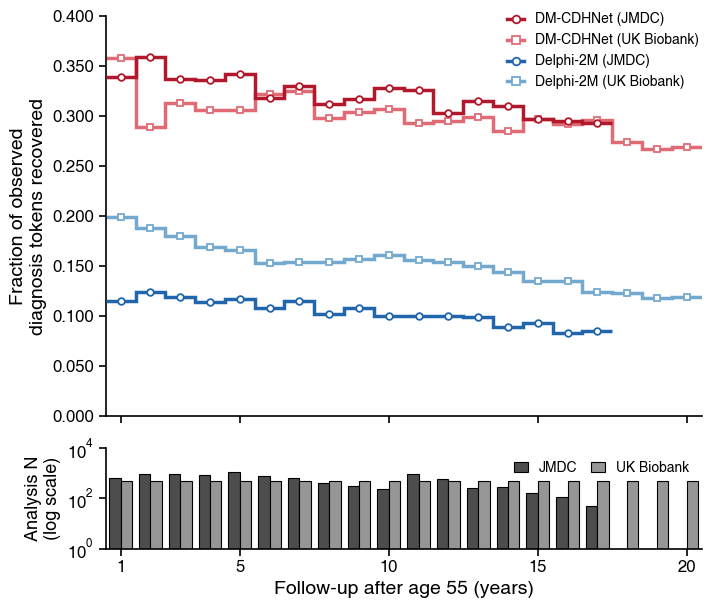

In [64]:
overlay_figure = draw_jmdc_ukb_overlay()
overlay_png, overlay_pdf = save_figure(overlay_figure, 'long_followup_recovery')
display(overlay_figure)
plt.close(overlay_figure)